TF-IDF + Logistic Regression

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [35]:
df = pd.read_csv("../data/clean_reviews.csv")

df = df.dropna(subset=["processed_text", "helpful_label"])
df["processed_text"] = df["processed_text"].astype(str)

print("Duplicate processed_text:", df["processed_text"].duplicated().sum())

df = df.drop_duplicates(subset=["processed_text"])
df = df.reset_index(drop=True)

X = df["processed_text"]
y = df["helpful_label"]

print("Final df shape:", df.shape)
print("X length:", len(X))
print("y length:", len(y))
print(y.value_counts())

Duplicate processed_text: 37
Final df shape: (518, 17)
X length: 518
y length: 518
helpful_label
0    293
1    225
Name: count, dtype: int64


In [36]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.85
)

X_tfidf = vectorizer.fit_transform(X)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=0.1
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [40]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))
print()


Accuracy: 0.9807692307692307

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        59
           1       1.00      0.96      0.98        45

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104




In [45]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    model,
    X_tfidf,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Average CV Accuracy:", scores.mean())

Cross Validation Scores: [0.93269231 0.93269231 0.95192308 0.94174757 0.95145631]
Average CV Accuracy: 0.9421023151605677


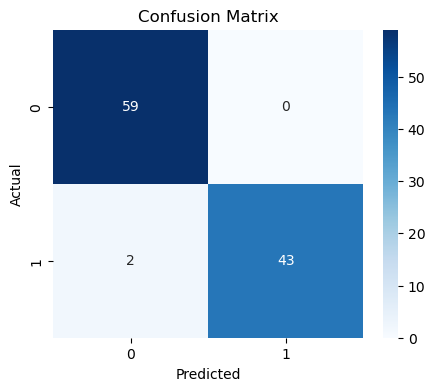

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [42]:
test_review = ["this game is very fun and detailed but it has many bugs and crashes"]

test_vector = vectorizer.transform(test_review)

prediction = model.predict(test_vector)[0]
probability = model.predict_proba(test_vector)[0]

if prediction == 1:
    print("Helpful Review")
else:
    print("Not Helpful Review")

print("Not Helpful Probability:", round(probability[0], 3))
print("Helpful Probability:", round(probability[1], 3))

Helpful Review
Not Helpful Probability: 0.34
Helpful Probability: 0.66


In [43]:
os.makedirs("../model", exist_ok=True)
with open("../model/helpfulness_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../model/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully in ../model/")

Model and vectorizer saved successfully in ../model/
